# CNN trained from scratch

In [31]:
import shutil
from pathlib import Path

import os

import soundfile as sf

import librosa
import librosa.display
import IPython.display as ip
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [32]:
!pip install audformat

import audformat

!wget https://zenodo.org/record/7447302/files/emodb.zip #Getting the database

!unzip emodb.zip

db = audformat.Database.load('emodb')

#Separation of the dataset into training and testing

df_test = db['emotion.categories.test.gold_standard'].get()

df_train = db['emotion.categories.train.gold_standard'].get()

print(f'samples in train: {df_train.shape[0]}, and test: {df_test.shape[0]}')

--2026-09-28 20:19:10--  https://zenodo.org/record/7447302/files/emodb.zip
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/7447302/files/emodb.zip [following]
--2026-09-28 20:19:10--  https://zenodo.org/records/7447302/files/emodb.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 39981818 (38M) [application/octet-stream]
Saving to: ‘emodb.zip.4’

emodb.zip.4         100%[===================>]  38.13M  2.55MB/s    in 65s     

2026-09-28 20:20:15 (604 KB/s) - ‘emodb.zip.4’ saved [39981818/39981818]

Archive:  emodb.zip
replace emodb/db.emotion.categories.train.gold_standard.pkl? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: emodb/db.emotion.categories.train.gold_standard.pkl  
  inflating: emodb/wav/14b01Fc.wav   
  inflating: emodb/

In [33]:
os.chdir("/content/emodb/") #Changing the directory to work with the .wav files

In [34]:
def window_utterance(file_path, label, speaker, window_sec=2.0, hop_sec=0.5, sr=16000):

    duration = sf.info(file_path).duration
    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)

    total_samples = int(duration * sr)
    starts = range(0, total_samples - window_samples + 1, hop_samples)

    windows = []
    for s in starts:
        windows.append({
            'file': file_path,
            'start': s / sr,
            'end': (s + window_samples) / sr,
            'label': label,
            'speaker': speaker
        })
    return windows

In [35]:
def get_speaker(filename):
    return Path(filename).stem[:2]

In [36]:
all_windows = []
# Slicing the audio files to increase the amount of data
for f, label in zip(df_train.index.get_level_values('file'), df_train['emotion']):
    all_windows.extend(window_utterance(f, label, get_speaker(f), window_sec=1.0, hop_sec=0.5))

train_df = pd.DataFrame(all_windows)
print(train_df.shape, train_df['speaker'].nunique())

(1217, 5) 6


In [37]:
train_df

,file,start,end,label,speaker
0,wav/03a01Fa.wav,0.0,1.0,happiness,03
1,wav/03a01Fa.wav,0.5,1.5,happiness,03
2,wav/03a01Nc.wav,0.0,1.0,neutral,03
3,wav/03a01Nc.wav,0.5,1.5,neutral,03
4,wav/03a01Wa.wav,0.0,1.0,anger,03
...,...,...,...,...,...
1212,wav/13b10Wa.wav,1.0,2.0,anger,13
1213,wav/13b10Wc.wav,0.0,1.0,anger,13
1214,wav/13b10Wc.wav,0.5,1.5,anger,13
1215,wav/13b10Wc.wav,1.0,2.0,anger,13


In [38]:
list_spectograms = []

# Creating the mel spectogram to each of the slices of audio
for idx, init, end in zip(train_df['file'], train_df['start'], train_df['end']):
  y, sr = librosa.load(idx, sr=16000)

  idx_init = int(init * sr)
  idx_end = int(end * sr)

  y_sliced = y[idx_init:idx_end]

  mel_spectogram = librosa.feature.melspectrogram(y=y_sliced, sr=sr)
  log_mel_spectogram = librosa.power_to_db(mel_spectogram)

  list_spectograms.append(log_mel_spectogram)

X_train = np.array(list_spectograms)
X_train = np.expand_dims(X_train, axis=-1) # The input of a 2D convolution is a 4D Tensor
Y_train_raw = np.array(train_df['label'])

In [39]:
print(X_train.shape)
print(Y_train_raw.shape)

(1217, 128, 32, 1)
(1217,)


In [40]:
all_windows = []
# Slicing the audio files to increase the amount of data
for f, label in zip(df_test.index.get_level_values('file'), df_test['emotion']):
    all_windows.extend(window_utterance(f, label, get_speaker(f), window_sec=1.0, hop_sec=0.5))

test_df = pd.DataFrame(all_windows)
print(test_df.shape, test_df['speaker'].nunique())

(958, 5) 4


In [41]:
test_df

,file,start,end,label,speaker
0,wav/12a01Fb.wav,0.0,1.0,happiness,12
1,wav/12a01Fb.wav,0.5,1.5,happiness,12
2,wav/12a01Lb.wav,0.0,1.0,boredom,12
3,wav/12a01Lb.wav,0.5,1.5,boredom,12
4,wav/12a01Nb.wav,0.0,1.0,neutral,12
...,...,...,...,...,...
953,wav/16b10Wa.wav,1.0,2.0,anger,16
954,wav/16b10Wb.wav,0.0,1.0,anger,16
955,wav/16b10Wb.wav,0.5,1.5,anger,16
956,wav/16b10Wb.wav,1.0,2.0,anger,16


In [42]:
list_spectograms = []

# Creating the mel spectogram to each of the slices of audio
for idx, init, end in zip(test_df['file'], test_df['start'], test_df['end']):
  y, sr = librosa.load(idx, sr=16000)

  idx_init = int(init * sr)
  idx_end = int(end * sr)

  y_sliced = y[idx_init:idx_end]

  mel_spectogram = librosa.feature.melspectrogram(y=y_sliced, sr=sr)
  log_mel_spectogram = librosa.power_to_db(mel_spectogram)

  list_spectograms.append(log_mel_spectogram)

X_test = np.array(list_spectograms)
Y_test_raw = np.array(test_df['label'])

encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train_raw)
Y_test = encoder.transform(Y_test_raw)

In [43]:
print(X_test.shape)
X_test = np.expand_dims(X_test, axis=-1) # The input of a 2D convolution is a 4D Tensor
print(Y_test.shape)

(958, 128, 32)
(958,)


In [44]:
# Normalizing the data
mean_val = np.mean(X_train)
std_val = np.std(X_train)

X_train = (X_train - mean_val) / std_val
X_test = (X_test - mean_val) / std_val

In [45]:
# Definition of the model
def build_audio_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.1),

        # Block 2
        layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.2),

        # Block 3
        layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        # Block 4
        layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-3)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [46]:
# Creating the model
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3])
num_classes = 7

model = build_audio_cnn(input_shape, num_classes)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 32, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 32, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 8, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 4, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 4, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 4, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 4, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 4, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 250,375 (978.03 KB)

 Trainable params: 249,671 (975.28 KB)

 Non-trainable params: 704 (2.75 KB)

In [47]:
historic = model.fit(
    x=X_train,
    y=Y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.3412 - loss: 1.8510 - val_accuracy: 0.1230 - val_loss: 2.2906
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - accuracy: 0.4635 - loss: 1.4865 - val_accuracy: 0.1230 - val_loss: 3.0709
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.4974 - loss: 1.3770 - val_accuracy: 0.1230 - val_loss: 4.4224
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - accuracy: 0.5488 - loss: 1.2584 - val_accuracy: 0.1230 - val_loss: 5.4057
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - accuracy: 0.5498 - loss: 1.2137 - val_accuracy: 0.1230 - val_loss: 5.9892
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - accuracy: 0.5694 - loss: 1.1490 - val_accuracy: 0.1230 - val_loss: 6.3005
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.6269 - loss: 1.0916 - val_accuracy: 0.1230 - val_loss: 6.9568
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - accuracy: 0.6259 - loss: 1.0295 - val_accura

In [48]:
model.evaluate(
    X_test,
    Y_test
)

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5251 - loss: 2.5106


[2.5106282234191895, 0.5250521898269653]

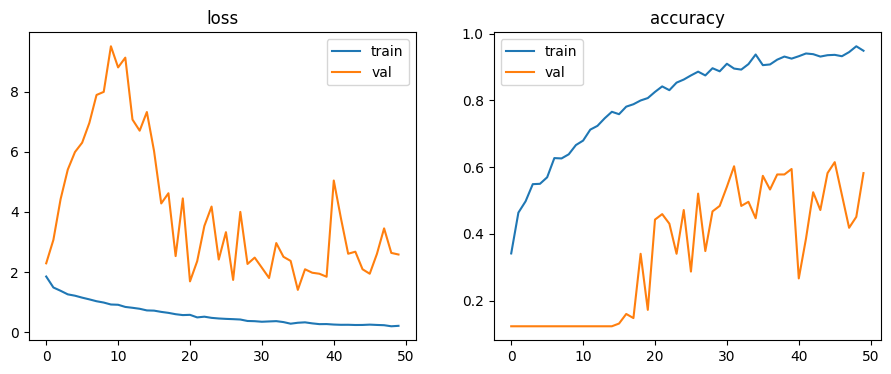

train window-level accuracy: 0.9199178814888
val window-level accuracy: 0.5843621492385864
test window-level accuracy: 0.5250521898269653
utterance-level test accuracy: 0.5627705627705628
              precision    recall  f1-score   support

       anger       0.72      0.89      0.80        55
     boredom       0.69      0.31      0.42        36
     disgust       0.00      0.00      0.00        26
        fear       0.75      0.36      0.49        33
   happiness       0.24      0.44      0.32        27
     neutral       0.45      0.85      0.59        27
     sadness       0.74      0.85      0.79        27

    accuracy                           0.56       231
   macro avg       0.51      0.53      0.49       231
weighted avg       0.55      0.56      0.52       231

[[49  0  0  0  6  0  0]
 [ 0 11  0  0  3 17  5]
 [ 4  0  0  4 12  5  1]
 [ 1  0  0 12 16  4  0]
 [14  0  0  0 12  1  0]
 [ 0  2  0  0  0 23  2]
 [ 0  3  0  0  0  1 23]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
# loss/accuracy
hist = historic.history
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (k, title) in zip(ax, [('loss', 'loss'), ('accuracy', 'accuracy')]):
    a.plot(hist[k], label='train'); a.plot(hist['val_' + k], label='val')
    a.set_title(title); a.legend()
plt.show()

# Window-level accuracy (train/val/test)
n_val = int(0.2 * len(X_train))
X_tr, X_val = X_train[:-n_val], X_train[-n_val:]
y_tr, y_val = Y_train[:-n_val], Y_train[-n_val:]

for name, X, y in [('train', X_tr, y_tr), ('val', X_val, y_val), ('test', X_test, Y_test)]:
    print(name, 'window-level accuracy:', model.evaluate(X, y, verbose=0)[1])

# Utterance-level accuracy
probs = model.predict(X_test, batch_size=64, verbose=0)
df_p = pd.DataFrame(probs)
df_p['file'] = test_df['file'].values

utt_probs = df_p.groupby('file').mean()
utt_true = pd.Series(Y_test, index=test_df['file'].values).groupby(level=0).first().loc[utt_probs.index]
utt_pred = utt_probs.values.argmax(axis=1)

print('utterance-level test accuracy:', (utt_pred == utt_true.values).mean())
print(classification_report(utt_true.values, utt_pred, target_names=encoder.classes_))
print(confusion_matrix(utt_true.values, utt_pred))